In [1]:
import kagglehub
import os
import pandas as pd
import glob
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

C:\Users\naman yadav\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gustavomodelli/forest-fires-in-brazil")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\naman yadav\.cache\kagglehub\datasets\gustavomodelli\forest-fires-in-brazil\versions\1


In [3]:
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)

if not csv_files:
    raise FileNotFoundError("No CSV file found in the dataset directory.")

df = pd.read_csv(csv_files[0], encoding='latin-1')

In [4]:
df.shape

(6454, 5)

In [5]:
df.isnull().sum()   

year      0
state     0
month     0
number    0
date      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(32)

In [7]:
df['date'].duplicated().sum()

np.int64(6434)

In [8]:
df['year'].value_counts()

year
1998    324
1999    324
2000    324
2001    324
2002    324
2003    324
2004    324
2005    324
2006    324
2007    324
2008    324
2009    324
2010    324
2011    324
2012    324
2013    324
2014    324
2015    324
2016    324
2017    298
Name: count, dtype: int64

In [9]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

In [10]:
df['state'].value_counts()

state
Rio                 717
Mato Grosso         478
Paraiba             478
Alagoas             240
Acre                239
Amapa               239
Amazonas            239
Bahia               239
Ceara               239
Distrito Federal    239
Espirito Santo      239
Goias               239
Maranhao            239
Minas Gerais        239
Pará                239
Pernambuco          239
Piau                239
Rondonia            239
Roraima             239
Santa Catarina      239
Sao Paulo           239
Sergipe             239
Tocantins           239
Name: count, dtype: int64

In [11]:
df['month'].value_counts()

month
Janeiro      541
Fevereiro    540
Março        540
Abril        540
Maio         540
Junho        540
Julho        540
Agosto       540
Setembro     540
Outubro      540
Novembro     540
Dezembro     513
Name: count, dtype: int64

In [12]:
df['month'] = df['month'].replace({
    'Janeiro' : 'Janeiro(jan)',
    'Fevereiro' : 'Fevereiro(feb)',
    'Março' : 'Março(mar)',
    'Abril' : 'Abril(apr)',
    'Maio' : 'Maio(may)',
    'Junho' : 'Junho(jun)',
    'Julho' : 'Julho(jul)',
    'Agosto' : 'Agosto(aug)',
    'Setembro' : 'Setembro(sep)',
    'Outubro' : 'Outubro(oct)',
    'Novembro' : 'Novembro(nov)',
    'Dezembro' : 'Dezembro(dec)'

})

In [13]:
df['year'].value_counts()

year
1998    324
1999    324
2000    324
2001    324
2002    324
2003    324
2004    324
2005    324
2006    324
2007    324
2008    324
2009    324
2010    324
2011    324
2012    324
2013    324
2014    324
2015    324
2016    324
2017    298
Name: count, dtype: int64

In [14]:
top10_states = df['state'].value_counts().head(10).index

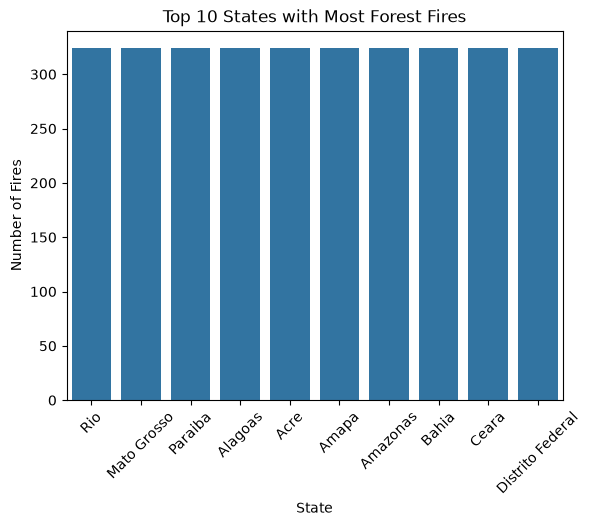

In [15]:
plt.Figure(figsize=(14, 8))
sns.barplot(x=df['state'].value_counts().head(10).index, y=df['year'].value_counts().head(10).values)
plt.xlabel('State')
plt.ylabel('Number of Fires')
plt.title('Top 10 States with Most Forest Fires')
plt.xticks(rotation=45)
plt.show()

In [16]:
top10_year_number = df['year'].value_counts().head(10).index

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '2002'),
  Text(1, 0, '2003'),
  Text(2, 0, '2004'),
  Text(3, 0, '2009'),
  Text(4, 0, '2010'),
  Text(5, 0, '2012'),
  Text(6, 0, '2014'),
  Text(7, 0, '2015'),
  Text(8, 0, '2016'),
  Text(9, 0, '2017')])

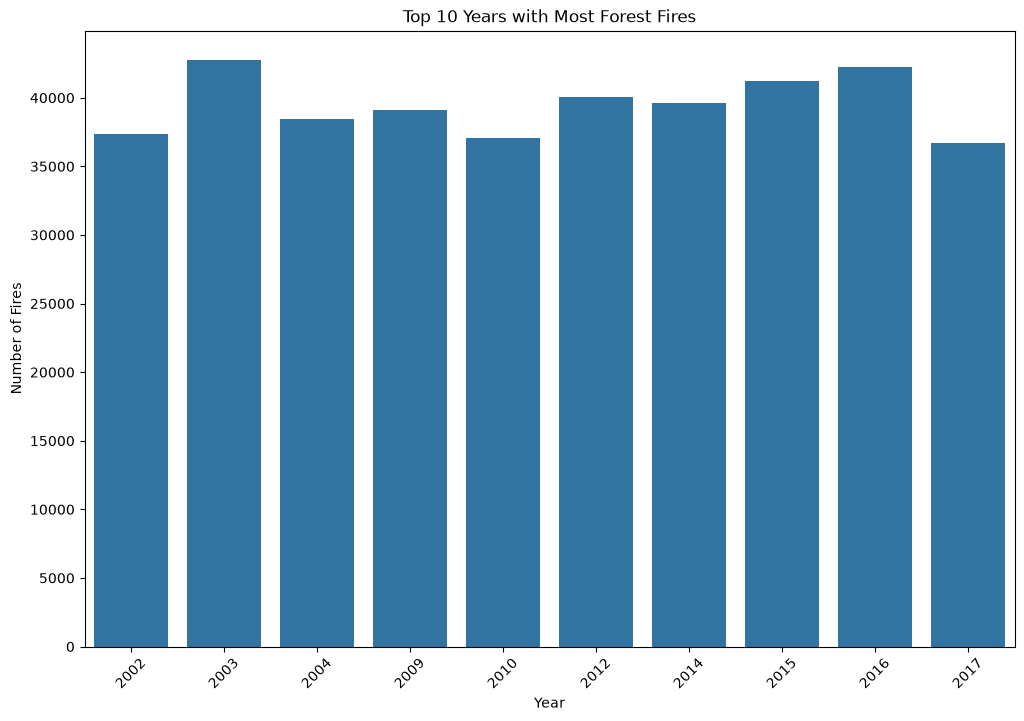

In [21]:
plt.figure(figsize=(12, 8))
year_fire_counts = df.groupby('year')['number'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=year_fire_counts.index, y=year_fire_counts.values)
plt.xlabel('Year')
plt.ylabel('Number of Fires')
plt.title('Top 10 Years with Most Forest Fires')
plt.xticks(rotation=45)
    

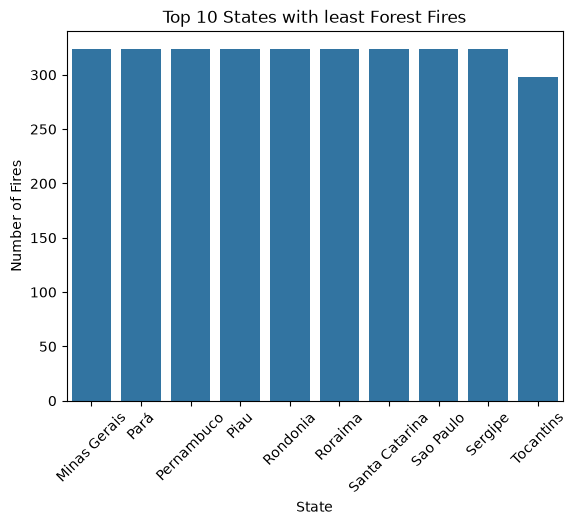

In [20]:
plt.Figure(figsize=(14, 8))
sns.barplot(x=df['state'].value_counts().tail(10).index, y=df['year'].value_counts().tail(10).values)
plt.xlabel('State')
plt.ylabel('Number of Fires')
plt.title('Top 10 States with least Forest Fires')
plt.xticks(rotation=45)
plt.show()

C:\Users\naman yadav\AppData\Local\Temp\ipykernel_56900\3132663496.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, ax=ax2, palette='Reds_r')
C:\Users\naman yadav\AppData\Local\Temp\ipykernel_56900\3132663496.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_states.values, y=bottom_states.index, ax=ax3, palette='Blues_r')
C:\Users\naman yadav\AppData\Local\Temp\ipykernel_56900\3132663496.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_sum.values, y=month_sum.index, ax=ax4,

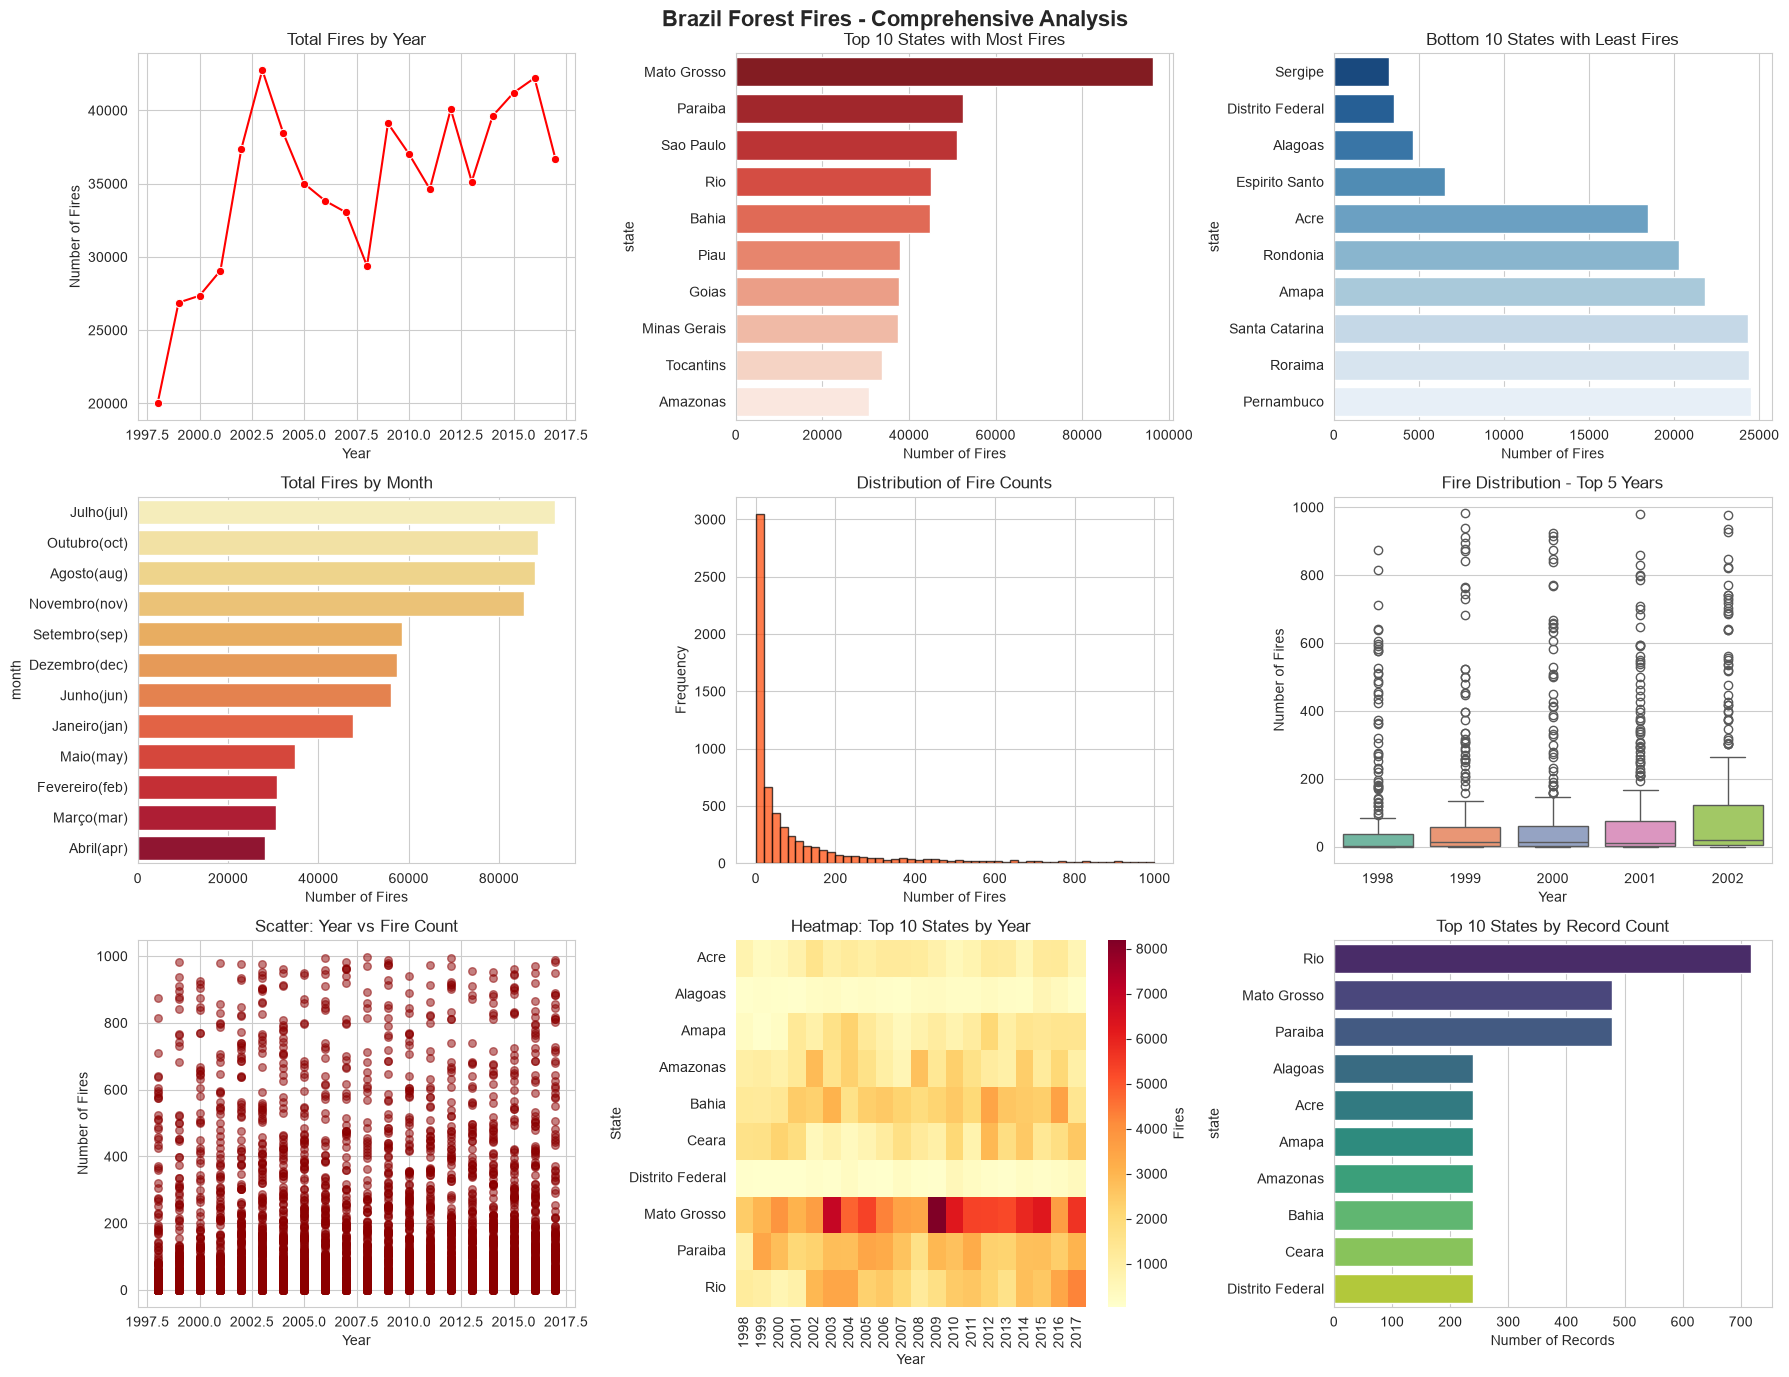

In [22]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create a figure with multiple subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Brazil Forest Fires - Comprehensive Analysis', fontsize=16, fontweight='bold')

# 1. Fires by Year
ax1 = axes[0, 0]
year_sum = df.groupby('year')['number'].sum()
sns.lineplot(x=year_sum.index, y=year_sum.values, ax=ax1, marker='o', color='red')
ax1.set_title('Total Fires by Year')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Fires')

# 2. Top 10 States by Fires
ax2 = axes[0, 1]
top_states = df.groupby('state')['number'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_states.values, y=top_states.index, ax=ax2, palette='Reds_r')
ax2.set_title('Top 10 States with Most Fires')
ax2.set_xlabel('Number of Fires')

# 3. Bottom 10 States by Fires
ax3 = axes[0, 2]
bottom_states = df.groupby('state')['number'].sum().sort_values(ascending=True).head(10)
sns.barplot(x=bottom_states.values, y=bottom_states.index, ax=ax3, palette='Blues_r')
ax3.set_title('Bottom 10 States with Least Fires')
ax3.set_xlabel('Number of Fires')

# 4. Fires by Month
ax4 = axes[1, 0]
month_sum = df.groupby('month')['number'].sum().sort_values(ascending=False)
sns.barplot(x=month_sum.values, y=month_sum.index, ax=ax4, palette='YlOrRd')
ax4.set_title('Total Fires by Month')
ax4.set_xlabel('Number of Fires')

# 5. Distribution of Fires (Histogram)
ax5 = axes[1, 1]
ax5.hist(df['number'], bins=50, color='orangered', edgecolor='black', alpha=0.7)
ax5.set_title('Distribution of Fire Counts')
ax5.set_xlabel('Number of Fires')
ax5.set_ylabel('Frequency')

# 6. Box Plot - Fires by Year (Top 5 years)
ax6 = axes[1, 2]
top_5_years = df['year'].value_counts().head(5).index
df_top_years = df[df['year'].isin(top_5_years)]
sns.boxplot(x='year', y='number', data=df_top_years, ax=ax6, palette='Set2')
ax6.set_title('Fire Distribution - Top 5 Years')
ax6.set_xlabel('Year')
ax6.set_ylabel('Number of Fires')

# 7. Scatter Plot - Year vs Number of Fires
ax7 = axes[2, 0]
ax7.scatter(df['year'], df['number'], alpha=0.5, color='darkred', s=30)
ax7.set_title('Scatter: Year vs Fire Count')
ax7.set_xlabel('Year')
ax7.set_ylabel('Number of Fires')

# 8. Heatmap - Top 10 States by Year
ax8 = axes[2, 1]
pivot_data = df[df['state'].isin(top10_states)].pivot_table(
    index='state', columns='year', values='number', aggfunc='sum', fill_value=0
)
sns.heatmap(pivot_data, ax=ax8, cmap='YlOrRd', cbar_kws={'label': 'Fires'})
ax8.set_title('Heatmap: Top 10 States by Year')
ax8.set_xlabel('Year')
ax8.set_ylabel('State')

# 9. Count Plot - Number of Records per State (Top 10)
ax9 = axes[2, 2]
state_counts = df['state'].value_counts().head(10)
sns.barplot(x=state_counts.values, y=state_counts.index, ax=ax9, palette='viridis')
ax9.set_title('Top 10 States by Record Count')
ax9.set_xlabel('Number of Records')

plt.tight_layout()
plt.show()